# 05 — Worked example: 200 MW hyperscale facility

End-to-end pricing of one annual policy for a 200 MW Tier-IV facility, using assumptions consistent with §12 of the paper. Reproduces the pure premium, three loaded premiums, and an XoL ceded-loss closed-form check.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dcrisk.frequency.nb_gamma import sample_NB
from dcrisk.severity.gpd import GPD
from dcrisk.severity.lognormal import Lognormal
from dcrisk.severity.mixture import BodyTailMixture
from dcrisk.pricing.pure import pure_premium
from dcrisk.pricing.loadings import sd_premium, variance_premium, esscher_premium, wang_premium
from dcrisk.pricing.xol import xol_expected_ceded, xol_expected_ceded_gpd

rng = np.random.default_rng(2026)

# --- facility & calibration ---
MW = 200            # facility size
u = 0.5             # POT threshold ($M)
body = Lognormal(mu=np.log(0.10), sigma=1.10)
tail = GPD(xi=0.32, sigma=0.80, threshold=u)
mix = BodyTailMixture(body=body, tail=tail, threshold=u, p_tail=0.10)

# --- annual frequency ---
nu, lam_bar = 3.0, 2.5 * MW / 200  # scales linearly with facility size
n_sims = 50_000
counts = sample_NB(nu, lam_bar, size=n_sims, rng=rng)
S = np.array([mix.sample(int(c), rng).sum() if c > 0 else 0.0 for c in counts])

In [2]:
print('--- Annual aggregate loss S (in $M) ---')
print(f'E[S]          = {pure_premium(S):>8,.3f}')
print(f'SD(S)         = {S.std(ddof=1):>8,.3f}')
print(f'99% VaR       = {np.quantile(S, 0.99):>8,.3f}')
print(f'99.5% VaR     = {np.quantile(S, 0.995):>8,.3f}')
print()
print('--- Loaded premiums ---')
print(f'Std-Dev (a=0.5)   = {sd_premium(S, 0.5):>8,.3f}')
print(f'Variance (a=0.05) = {variance_premium(S, 0.05):>8,.3f}')
print(f'Esscher (h=0.05)  = {esscher_premium(S, 0.05):>8,.3f}')
print(f'Wang   (lam=0.3)  = {wang_premium(S, 0.3):>8,.3f}')
print()
print('--- XoL ceded loss (d=2.0, ell=8.0) ---')
print(f'Monte Carlo on S  = {xol_expected_ceded(S, d=2.0, ell=8.0):>8,.3f}')
p_u = (S > u).mean()
print(f'GPD closed form    = {xol_expected_ceded_gpd(tail, d=2.0, p_u=p_u, ell=8.0):>8,.3f}')

--- Annual aggregate loss S (in $M) ---
E[S]          =    0.828
SD(S)         =    1.438
99% VaR       =    6.480
99.5% VaR     =    8.301

--- Loaded premiums ---
Std-Dev (a=0.5)   =    1.547
Variance (a=0.05) =    0.931
Esscher (h=0.05)  =    0.969
Wang   (lam=0.3)  =    1.203

--- XoL ceded loss (d=2.0, ell=8.0) ---
Monte Carlo on S  =    0.187
GPD closed form    =    0.163


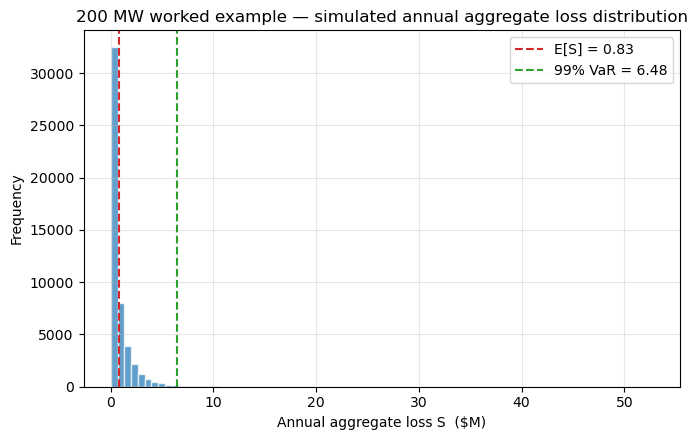

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(S, bins=80, color='C0', alpha=0.7, edgecolor='white')
ax.axvline(pure_premium(S), color='C3', ls='--', label=f'E[S] = {pure_premium(S):.2f}')
ax.axvline(np.quantile(S, 0.99), color='C2', ls='--', label=f'99% VaR = {np.quantile(S, 0.99):.2f}')
ax.set_xlabel('Annual aggregate loss S  ($M)')
ax.set_ylabel('Frequency')
ax.set_title('200 MW worked example — simulated annual aggregate loss distribution')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()